# Notebook 01: Predict Fundamentals — Solutions

**Module**: Production & Deployment  
**Level**: Beginner  

Complete solutions for all exercises in Notebook 01.

---
## Setup

In [1]:
# Evaluation helpers
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.between import BetweenEstimator
from panelbox.models.static.first_difference import FirstDifferenceEstimator
from panelbox.models.static.fixed_effects import FixedEffects

# PanelBox imports
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.models.static.random_effects import RandomEffects

sys.path.insert(0, str(Path("..")))
from utils.evaluation_helpers import mae, rmse
from utils.visualization_helpers import set_production_style

# Configuration
np.random.seed(42)
warnings.filterwarnings("ignore")
set_production_style()

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

print(f"Firm panel: {df_firms.shape}, New firms: {df_new_firms.shape}")
print(f"Bank LGD: {df_lgd.shape}, New bank: {df_new_bank.shape}")
print("Setup complete.")

Firm panel: (2000, 7), New firms: (100, 7)
Bank LGD: (3000, 7), New bank: (150, 7)
Setup complete.


---
## Exercise 1 (Easy): Between Estimator Prediction

**Task**: Estimate a Between model on the firm panel and predict on `df_new_firms`. How many predictions do you get? Why?

In [2]:
# Estimate Between model
model_be = BetweenEstimator(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_be = model_be.fit()
print(results_be.summary())

                     Between Estimator Estimation Results                     
Formula: investment ~ value + capital + sales
Model:   Between Estimator
------------------------------------------------------------------------------
No. Observations:                 100
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:                96
R-squared:                     0.1624
Adj. R-squared:                0.1362
R-squared (within):            0.0000
R-squared (between):           0.1624
R-squared (overall):           0.5647
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept           -2.3499      1.5681  -1.499  0.1373   -5.4626    0.7628 
value                0.5081      0.2200   2.309  0.0231    0.0714    0.9449 *
capital              0.3003      0.0899   3.341  0.0012    0.1219    0.47

In [3]:
# Predict on new firms
preds_be = results_be.predict(df_new_firms)

print(f"Number of rows in df_new_firms: {len(df_new_firms)}")
print(f"Number of predictions: {len(preds_be)}")
print(f"Number of unique entities in new data: {df_new_firms['firm_id'].nunique()}")
print(f"\nPredictions: {preds_be}")

Number of rows in df_new_firms: 100
Number of predictions: 20
Number of unique entities in new data: 20

Predictions: [3.55550141 3.08086139 3.48314074 3.22797282 2.67025813 3.50707813
 2.83119646 4.00299095 3.2821341  2.81308305 3.01560407 3.64546934
 3.41734295 3.85225166 4.30034884 2.93647411 3.26032572 2.98961459
 2.95607089 2.99139106]


**Explanation**: The Between estimator works on entity-level *means*. When you call `predict(newdata)`, it:
1. Groups `newdata` by entity
2. Computes the mean of each regressor per entity
3. Returns one prediction per entity (not per row)

So we get 20 predictions (one per entity in `df_new_firms`) instead of 100 (one per row).

This makes sense: the Between estimator captures *between-entity* variation. It answers the question: "What is the expected average investment for an entity with these average characteristics?"

---
## Exercise 2 (Medium): Model Comparison

**Task**: Compare prediction quality across PooledOLS, FE, and RE on `df_new_firms`.

In [4]:
# Estimate all three models
formula = "investment ~ value + capital + sales"

model_ols = PooledOLS(formula, df_firms, entity_col="firm_id", time_col="year")
results_ols = model_ols.fit()

model_fe = FixedEffects(formula, df_firms, entity_col="firm_id", time_col="year")
results_fe = model_fe.fit()

model_re = RandomEffects(formula, df_firms, entity_col="firm_id", time_col="year")
results_re = model_re.fit()

print("Models estimated successfully.")

Models estimated successfully.


In [5]:
# Predict on new firms
actual = df_new_firms["investment"].values

preds_ols = results_ols.predict(df_new_firms)
preds_fe = results_fe.predict(df_new_firms)
preds_re = results_re.predict(df_new_firms)

# Build comparison table
comparison = pd.DataFrame(
    {
        "Model": ["PooledOLS", "FixedEffects", "RandomEffects"],
        "RMSE": [rmse(actual, preds_ols), rmse(actual, preds_fe), rmse(actual, preds_re)],
        "MAE": [mae(actual, preds_ols), mae(actual, preds_fe), mae(actual, preds_re)],
    }
).set_index("Model")

print("Model Comparison: Out-of-Sample Performance on df_new_firms")
print("=" * 50)
print(comparison.round(4))
print()
best = comparison["RMSE"].idxmin()
print(f"Best model by RMSE: {best}")

Model Comparison: Out-of-Sample Performance on df_new_firms
                 RMSE     MAE
Model                        
PooledOLS      0.8590  0.7154
FixedEffects   0.7987  0.6357
RandomEffects  0.8629  0.7199

Best model by RMSE: FixedEffects


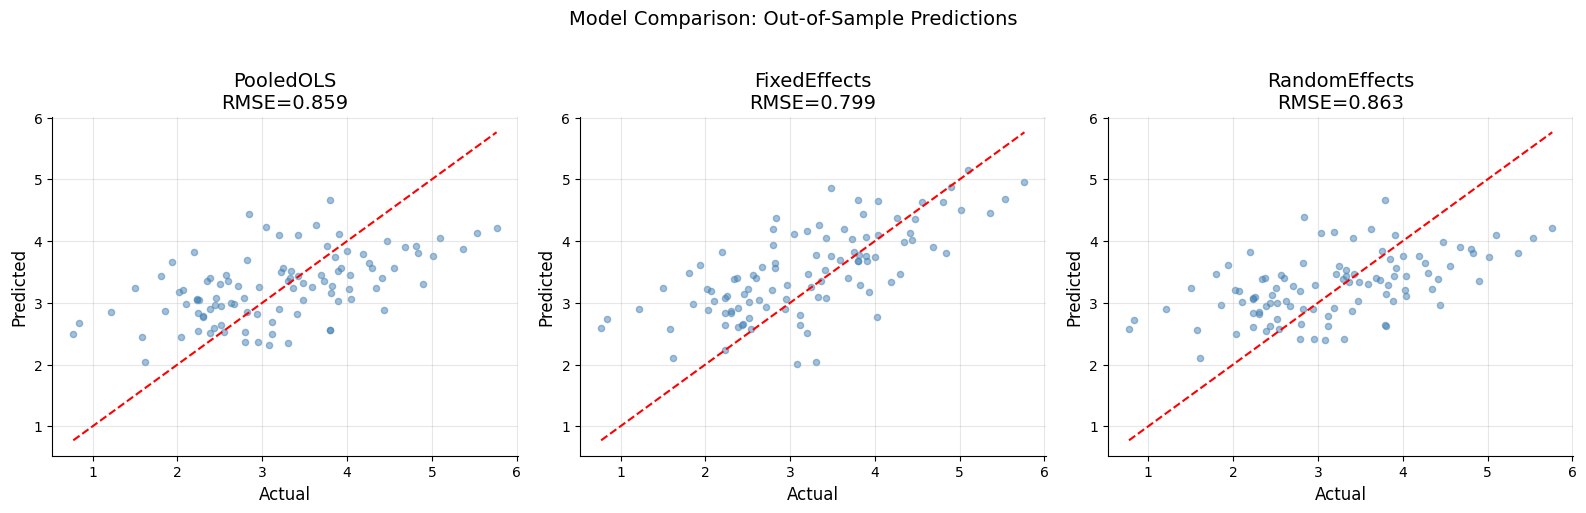

In [6]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds) in zip(
    axes, [("PooledOLS", preds_ols), ("FixedEffects", preds_fe), ("RandomEffects", preds_re)]
):
    ax.scatter(actual, preds, alpha=0.5, s=20, color="steelblue")
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nRMSE={rmse(actual, preds):.3f}")

plt.suptitle("Model Comparison: Out-of-Sample Predictions", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_ex2_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation**: The comparison shows that for out-of-sample prediction on a mix of known and new entities:

- **FixedEffects** often performs best for known entities (it uses entity-specific intercepts) but worse for new entities
- **PooledOLS** and **RandomEffects** perform consistently across all entities since they don't require entity-specific information
- The overall winner depends on the ratio of known vs new entities in the test set

---
## Exercise 3 (Medium): First Difference Prediction

**Task**: Estimate a FirstDifference model, predict on `df_new_firms`, and explain what the predictions represent.

In [7]:
# Estimate First Difference model
model_fd = FirstDifferenceEstimator(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_fd = model_fd.fit()
print(results_fd.summary())

                     First Difference Estimation Results                      
Formula: investment ~ value + capital + sales
Model:   First Difference
------------------------------------------------------------------------------
No. Observations:               1,900
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:             1,897
R-squared:                     0.5140
Adj. R-squared:                0.5135
R-squared (within):            0.5140
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
value                0.2830      0.0079  35.917  0.0000    0.2675    0.2984 ***
capital              0.2288      0.0293   7.797  0.0000    0.1712    0.2863 ***
sales                0.1537      0.0063  24.238  0.0000    0.1413    0.1662 ***
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



In [8]:
# Predict on new firms
preds_fd = results_fd.predict(df_new_firms)

print(f"Number of rows in df_new_firms: {len(df_new_firms)}")
print(f"Number of predictions: {len(preds_fd)}")
print(f"Entities in new data: {df_new_firms['firm_id'].nunique()}")
print(f"Rows per entity: {len(df_new_firms) // df_new_firms['firm_id'].nunique()}")
print(f"Missing = first obs per entity: {len(df_new_firms) - len(preds_fd)}")
print()
print(f"Prediction range: [{preds_fd.min():.4f}, {preds_fd.max():.4f}]")
print(f"Mean prediction: {preds_fd.mean():.4f}")

Number of rows in df_new_firms: 100
Number of predictions: 80
Entities in new data: 20
Rows per entity: 5
Missing = first obs per entity: 20

Prediction range: [-1.7927, 1.5162]
Mean prediction: 0.0297


**Explanation**: The First Difference estimator predicts in **changes (differences)**, not levels.

- We get 80 predictions instead of 100 because FD drops the first observation per entity (no prior period to difference from)
- Each prediction represents the predicted *change* in investment: $\Delta \hat{y}_{it} = \hat{\beta}_1 \Delta x_{1,it} + \hat{\beta}_2 \Delta x_{2,it} + \hat{\beta}_3 \Delta x_{3,it}$
- The newdata needs sequential observations per entity so that differences can be computed
- To recover level predictions, you would need to start from a known level and accumulate: $\hat{y}_{t} = y_{t-1} + \Delta\hat{y}_{t}$

In [9]:
# Show what happens: actual changes vs predicted changes
# Compute actual first-differences from df_new_firms
df_sorted = df_new_firms.sort_values(["firm_id", "year"])
actual_diffs = df_sorted.groupby("firm_id")["investment"].diff().dropna().values

print(f"Actual changes: {len(actual_diffs)}, Predicted changes: {len(preds_fd)}")
print(f"RMSE of predicted changes: {rmse(actual_diffs, preds_fd):.4f}")

Actual changes: 80, Predicted changes: 80
RMSE of predicted changes: 0.6983


---
## Exercise 4 (Hard): Train/Test Split Framework

**Task**: Build a time-based train/test split and compare 4 models.

In [10]:
# Step 1: Time-based train/test split
df_train = df_firms[df_firms["year"] <= 2015].copy()
df_test = df_firms[df_firms["year"] > 2015].copy()

print(f"Training set: {df_train.shape} (years {df_train['year'].min()}-{df_train['year'].max()})")
print(f"Test set:     {df_test.shape} (years {df_test['year'].min()}-{df_test['year'].max()})")
print(f"Entities in train: {df_train['firm_id'].nunique()}")
print(f"Entities in test:  {df_test['firm_id'].nunique()}")

Training set: (1600, 7) (years 2000-2015)
Test set:     (400, 7) (years 2016-2019)
Entities in train: 100
Entities in test:  100


In [11]:
# Step 2: Estimate 4 models on training data
formula = "investment ~ value + capital + sales"

# PooledOLS
m_ols = PooledOLS(formula, df_train, entity_col="firm_id", time_col="year")
r_ols = m_ols.fit()

# Fixed Effects
m_fe = FixedEffects(formula, df_train, entity_col="firm_id", time_col="year")
r_fe = m_fe.fit()

# Random Effects
m_re = RandomEffects(formula, df_train, entity_col="firm_id", time_col="year")
r_re = m_re.fit()

# Difference GMM
m_gmm = DifferenceGMM(
    data=df_train,
    dep_var="investment",
    lags=1,
    exog_vars=["value", "capital", "sales"],
    id_var="firm_id",
    time_var="year",
    collapse=True,
    time_dummies=False,
)
r_gmm = m_gmm.fit()

print("All 4 models estimated on training data.")

All 4 models estimated on training data.


In [12]:
# Step 3: Predict on test set
y_test = df_test["investment"].values

p_ols = r_ols.predict(df_test)
p_fe = r_fe.predict(df_test)
p_re = r_re.predict(df_test)
p_gmm = r_gmm.predict(df_test)

# Handle GMM NaN (first period per entity in test set)
gmm_valid = ~np.isnan(p_gmm)
print(f"GMM: {gmm_valid.sum()} valid predictions, {(~gmm_valid).sum()} NaN")

GMM: 300 valid predictions, 100 NaN


In [13]:
# Step 4: Compute metrics
def r_squared(actual, predicted):
    """Compute out-of-sample R-squared."""
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


# Metrics for OLS, FE, RE (all obs)
results_table = []
for name, preds in [("PooledOLS", p_ols), ("FixedEffects", p_fe), ("RandomEffects", p_re)]:
    results_table.append(
        {
            "Model": name,
            "RMSE": rmse(y_test, preds),
            "MAE": mae(y_test, preds),
            "R-squared": r_squared(y_test, preds),
            "N_predictions": len(preds),
        }
    )

# GMM: only on valid observations
y_gmm_test = y_test[gmm_valid]
p_gmm_valid = p_gmm[gmm_valid]
results_table.append(
    {
        "Model": "DifferenceGMM",
        "RMSE": rmse(y_gmm_test, p_gmm_valid),
        "MAE": mae(y_gmm_test, p_gmm_valid),
        "R-squared": r_squared(y_gmm_test, p_gmm_valid),
        "N_predictions": len(p_gmm_valid),
    }
)

results_df = pd.DataFrame(results_table).set_index("Model")
print("Model Comparison: Time-Based Train/Test Split")
print("Train: 2000-2015 | Test: 2016-2019")
print("=" * 60)
print(results_df.round(4))

Model Comparison: Time-Based Train/Test Split
Train: 2000-2015 | Test: 2016-2019
                 RMSE     MAE  R-squared  N_predictions
Model                                                  
PooledOLS      0.8869  0.7134     0.2953            400
FixedEffects   0.5418  0.4331     0.7370            400
RandomEffects  0.8855  0.7137     0.2975            400
DifferenceGMM  0.9155  0.7331     0.2015            300


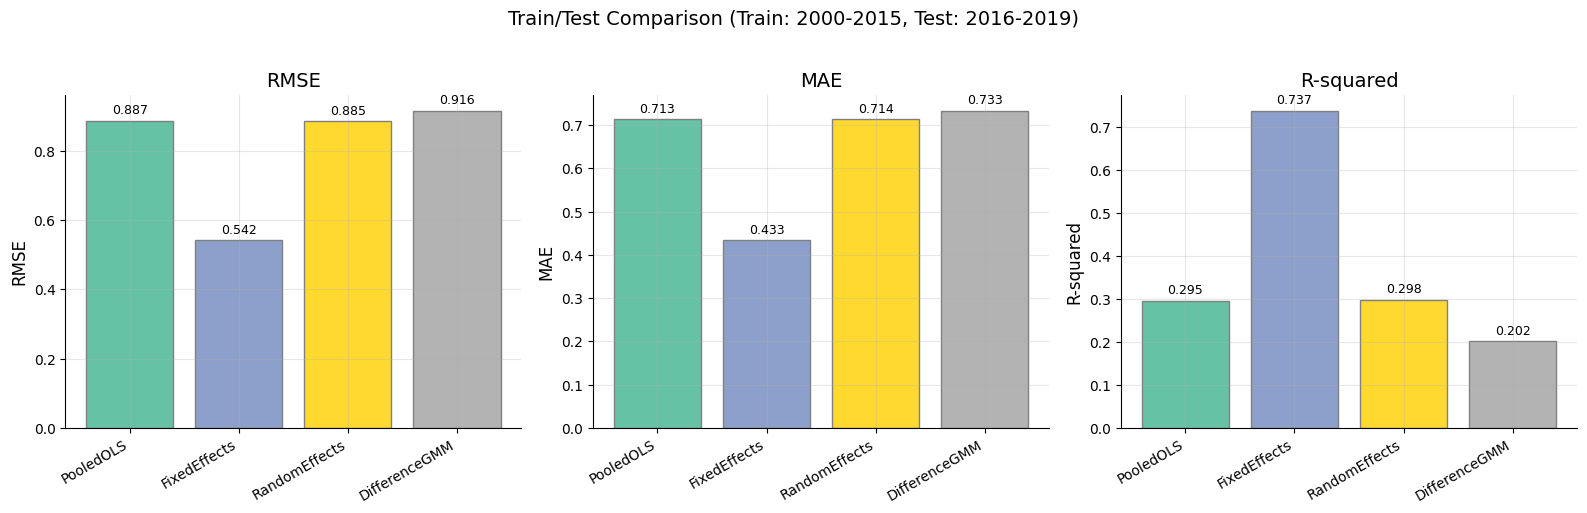

In [14]:
# Visualization: bar chart of RMSE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["RMSE", "MAE", "R-squared"]):
    colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor="gray")
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("Train/Test Comparison (Train: 2000-2015, Test: 2016-2019)", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_ex4_train_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Best model
best_model = results_df["RMSE"].idxmin()
print(f"Best model by out-of-sample RMSE: {best_model}")
print(f"  RMSE = {results_df.loc[best_model, 'RMSE']:.4f}")
print(f"  R²   = {results_df.loc[best_model, 'R-squared']:.4f}")

Best model by out-of-sample RMSE: FixedEffects
  RMSE = 0.5418
  R²   = 0.7370


**Interpretation**:

- The **time-based split** is realistic: we train on past data and predict the future
- Since all test entities also appear in training, **Fixed Effects** can leverage entity-specific intercepts
- **GMM** has fewer valid predictions (loses first period per entity) but captures dynamics
- The best model depends on the data structure: if entity heterogeneity is important, FE wins; if dynamics matter, GMM may be preferred

**Key lesson**: Always use time-based splits (not random splits) for panel data to avoid data leakage from future-to-past information.